In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

### Luokkien määrittely

In [2]:
class Transmon:

    def __init__(self,E_C,E_J,N):

        self.E_C=E_C #Varausenergia
        self.E_J=E_J #Josephsonin energia
        self.N=N   

        self.phi = np.linspace(-np.pi, np.pi, N, endpoint=False) #vaiheoperaattori diskretisoituna välillä [-pi,pi] 1000 pisteeseen
        self.delta_phi = self.phi[2]-self.phi[1] #vaiheoperaattorin diskresitoitu askelväli

        M = np.eye(N,k=1)+np.eye(N,k=-1)-2*np.eye(N) #Muodostetaan numero-operaattorin neliön matriisiesitys differenssimenetelmällä
        M[0,-1]=1
        M[-1,0]=1
        n_squared = -M/(self.delta_phi**2)

        self.H_0 = 4*E_C*n_squared-E_J*np.diag(np.cos(self.phi)) #Hamiltonin operaattori

        energies, eigenstates = np.linalg.eigh(self.H_0) # Transmonin ominaisenergiat ja -tilat

        self.energies = energies #Ominaisenergiat
        self.eigenstates = eigenstates #Ominaistilat
        self.frequency = energies[1]-energies[0] #Kubitin taajuus
    
    def H_D_eigbasis(self,dim): #Ajettu Hamiltonin operaattori ominaiskannassa
 
        H_0 = np.diag(self.energies[0:dim]-self.energies[0]) #Diagonaalimatriisi ominaisenergioista (lukumäärä ensimmäiset dim)

        M = np.zeros((dim, dim))
        vals = np.sqrt(np.arange(1, dim))
        M[np.arange(dim-1), np.arange(1, dim)] = vals      
        M[np.arange(1, dim), np.arange(dim-1)] = vals

        def H_t(A): return H_0 + A*M

        return H_t
    
class time_evolution:

    def __init__(self,generator):
        self.generator = generator
    
    def U(self, A, dt): return expm(-1j * self.generator(A) * dt) #Aikaevoluutio-operaattori

    def U_floquet(self, A_vals, dt): #Floquet-operaattori

        U_f = self.U(0, 0) #Aikakehitysoperaattori yhdelle Floquet-jaksolle
        for A in A_vals: 
            U_f = self.U(A, dt) @ U_f
        return U_f

class Pulse:

    def __init__(self,frequency,f_supp,pulse_funcs,pulse_times,time_unit=1):

        #Tarkistetaan, että on annettu sama määrä pulssifunktiota ja -aikoja
        if len(pulse_times)!=len(pulse_funcs):
            raise Exception("Pulse function and time interval arrays must have the same size") 

        #Määritellään ajan arvot eri pulssin osille
        piecewise_time_vals=[(np.arange(time)*time_unit) for time in pulse_times]

        #Ajan arvot koko pulssin ajalle
        self.time_vals = np.arange(np.sum(pulse_times))*time_unit

        #Pulssin amplitudi määriteltynä osissa
        self.piecewise_envelope_vals=[np.array([pulse_funcs[i](t) for t in piecewise_time_vals[i]]) for i in range(0,len(piecewise_time_vals))]

        #Pulssin amplitudi
        self.envelope = np.concatenate(self.piecewise_envelope_vals)

        #Derivaatta amplitudifunktiosta
        self.envelope_derivative = np.gradient(self.envelope,time_unit)
        
        #Määritellään signaalin vaihe siten, että amplitudi on nolla toisen jakson alussa
        #offset=frequency*pulse_times[0]
        offset=0

        #Aikapisteiden määrä
        N=len(self.time_vals)

        signal=np.zeros(N)
        cosine_signal=np.zeros(N)
        self.drag_component=np.zeros(N)

        #Määritellään signaali sini- ja kosinifunktioiden avulla, käyttäen taajuutta amplitudin funktiona
        signal = np.sin(frequency*self.time_vals-offset)
        cosine_signal = np.cos(frequency*self.time_vals-offset)

        #DRAG-komponentti pulssille
        self.drag_component = self.envelope_derivative * cosine_signal / (f_supp-frequency)

        #Signaalin arvot moduloituna amplitudilla
        self.raw = self.envelope*signal        

        #Määritellään DRAG-pulssi, ja sen fouriermuunnos
        self.drag_pulse = self.raw + self.drag_component

### Funktioita pulssimuotojen muodostamiseen

In [3]:
def zero(t): #Nollafunktio
    return 0

def one(t): #Ykkösfunktio
    return 1

def linear(k,t_0,c): #Suora
    return lambda t: k*(t-t_0)+c

def linear_opp(k,t_0,c): #Suora -t-funktiona
    return lambda t: k*(t_0-t)+c

def arctan(t_0,c): #Arkustangentti skaalattuna välille [-1,1], siirrettynä t_0 verran ajassa
    return lambda t: np.arctan(c*(t-t_0))/np.pi+0.5

def arctan_opp(t_0,c): #Arkustangentti -t-funktiona, siirrettynä -t_0 verran ajassa. Pulssin laskevaa reunaa varten
    return lambda t: np.arctan(c*(t_0-t))/np.pi+0.5

def gaussian(t_0,sigma): #Normalisoitu Gaussinen funktio keskihajonnalla sigma, ja keskipisteellä t_0.
    return lambda t: np.exp(-((t-t_0)**2)/(2*sigma**2))
    
def gaussian_opp(t_0,sigma): #Normalisoitu Gaussinen funktio keskihajonnalla sigma, ja keskipisteellä -t_0. Pulssin laskevaa reunaa varten
    return lambda t: np.exp(-((t+t_0)**2)/(2*sigma**2))

### Transmonin määrittely

In [4]:
E_C = 0.3 #Varausenergia (GHz)
E_J = 8 #Josephsonin energia (GHz)

qubit=Transmon(E_C,E_J,500)

In [5]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[ 0.          4.0566369   7.73020385 11.07420845 13.12309129 17.41456479
 17.57786409 25.51228464 25.51356975 36.14800094 36.14800387]


## Simulaatio

In [6]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus


In [7]:
dim = 7

evolution_eigenbasis=time_evolution(qubit.H_D_eigbasis(dim))

### Simulaatio alkuperäiselle pulssille

In [8]:
def sim_pulse(f_d,A,evolution,dim,f_rabi):
    T_floquet = 2*np.pi/(f_d) #Floquet-jakson pituus
    dt = T_floquet/20 #Diskretoidaan aika-avaruus siten, että Floquet-jakson pituus on 20 aikapistettä

    N_edge=int(10/dt) #Määritellään reunojen pituudeksi 10 ns (5ns ramppi + 5ns, jotta amplitudi menee lähemmäs nollaa)
    N_pulse=int(1/(f_rabi*dt)) #Määritellään pulssin pituus arvatun Rabi-taajuuden perusteella

    #Kokonainen pulssi rampin aikakehityksen laskemista varten
    pulse = Pulse(f_d,f_ef,[gaussian(10,2.5),one,gaussian_opp(0,2.5)],[N_edge,N_pulse,N_edge],time_unit=dt)

    #Alustetaan kubitin tila perustilaan
    psi_eig_accum = np.zeros(dim)
    psi_eig_accum[0] = 1

    #Lopulliset todennäköisyydet eripituisten pulssien jälkeen
    last_vals=[]

    for i in range(0, N_edge): #Aikakehitys rampille
        psi_eig_accum = evolution_eigenbasis.U(A*pulse.drag_pulse[i], dt) @ psi_eig_accum

    psi_eig = psi_eig_accum
    for i in range(0, N_edge): #Aikakehitys
        psi_eig = evolution_eigenbasis.U(A*pulse.drag_pulse[N_edge+i], dt) @ psi_eig
        
    last_vals.append(np.abs(psi_eig)**2)
    
    #Simulaatio pulsseille
    for k in range(1,N_pulse):
        
        pulse = Pulse(f_d,f_ef,[gaussian(10,2.5),one,gaussian_opp(0,2.5)],[N_edge,k,N_edge],time_unit=dt)
        
        psi_eig_accum = evolution_eigenbasis.U(A*pulse.drag_pulse[N_edge+k-1], dt) @ psi_eig_accum
        psi_eig = psi_eig_accum

        #Laskevan rampin simulaatio
        for i in range(0, N_edge): #Aikakehitys
            psi_eig = evolution_eigenbasis.U(A*pulse.drag_pulse[N_edge+k+i], dt) @ psi_eig
        last_vals.append(np.abs(psi_eig)**2)

    #e- ja f-tasojen lopulliset todennäköisyydet
    e_vals = np.array([a[1] for a in last_vals])
    f_vals = np.array([a[2] for a in last_vals])

    #e-tason suurin todennäköisyys
    excited_max=max(e_vals)
    #f-tason suurin todennäköisyys pulssille, jolla e-taso saavuttaa suurimman arvonsa
    f_max=max(f_vals)

    #Pulssin pituus määritettynä maksimiarvon sijainnin perusteella
    T_pulse = np.argmax(e_vals)*dt

    #Simuloitujen pulssien pituudet, plottausta varten
    pulse_times=np.arange(0,N_pulse)*dt
    
    return (excited_max,f_max,T_pulse,last_vals,pulse_times)

def find_params(q,A,evolution,f_rabi,AC_stark):

    #Rajat AC-stark siirtymälle
    min_range = -250
    max_range = 250

    f_d = q.frequency/3 #Ajotaajuus
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]
    
    for i in range(min_range,max_range):
        delta=AC_stark+i/10000 #AC-stark siirtymä
        AC_stark_vals.append(delta)

        sim_vals = sim_pulse(f_d+delta,A,evolution,dim,f_rabi)
        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_e_vals)
    plt.xlabel("AC-stark siirtymä")
    plt.ylabel("Suurin e-tason todennäköisyys")
    plt.show()
    
    index=np.argmax(max_e_vals)
    AC_stark=AC_stark_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(AC_stark,pi_pulse,[e_max,f_max],max_e_vals)

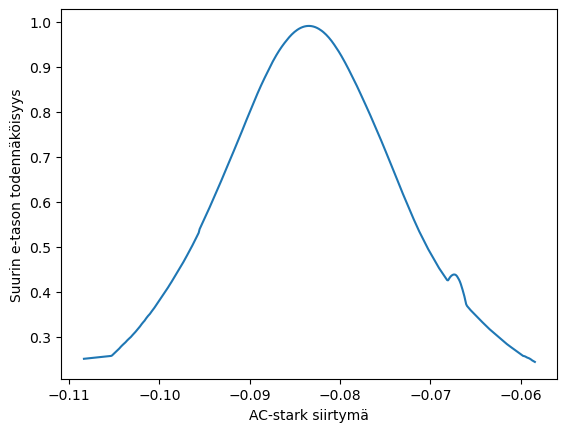

Amplitudi (GHz): 2.433982142182782
AC-stark siirtymä (GHz): -0.08344872975688583
E-tason suurin todennäköisyys: 0.9920026160375308
Pulssin pituus (ns): 68.83573719695245
Rabi-taajuus (fourier):  0.006877021898719922


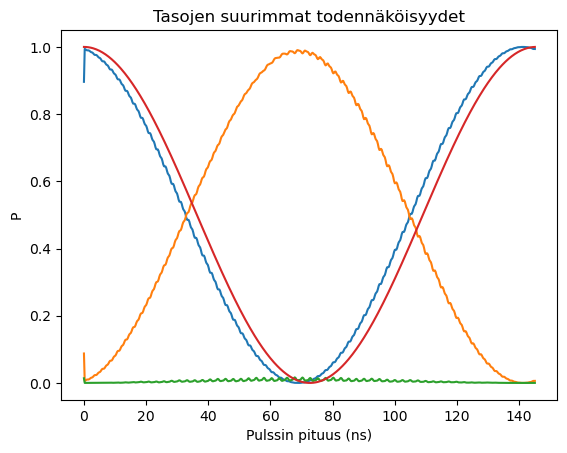

---------------------------------------------


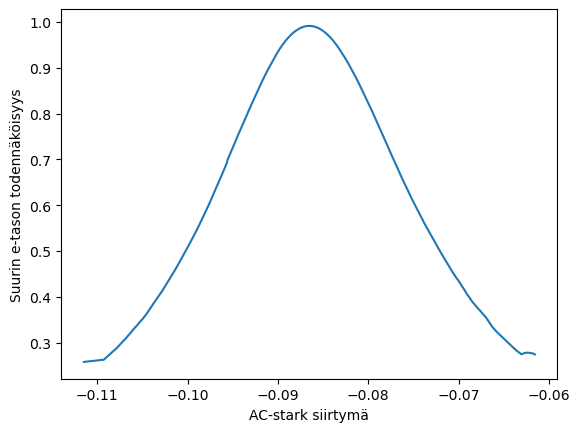

Amplitudi (GHz): 2.4745485112191616
AC-stark siirtymä (GHz): -0.08656238650514185
E-tason suurin todennäköisyys: 0.9919912735811922
Pulssin pituus (ns): 64.04068733441792
Rabi-taajuus (fourier):  0.007239853364106555


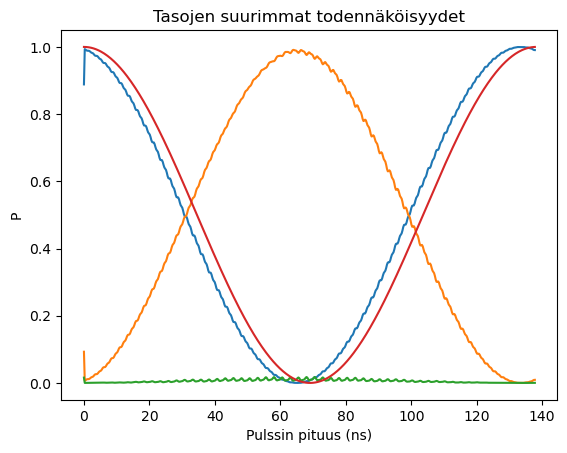

---------------------------------------------


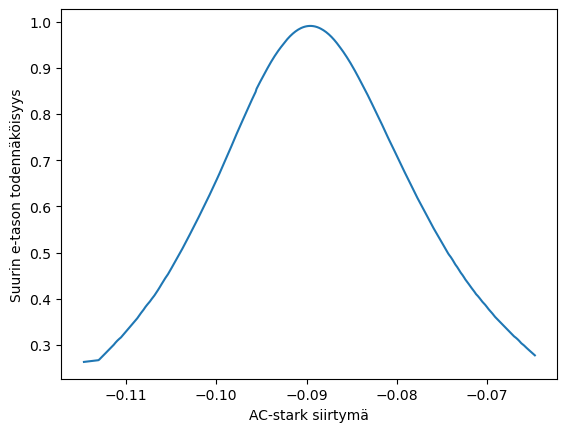

Amplitudi (GHz): 2.5151148802555414
AC-stark siirtymä (GHz): -0.08963107313052271
E-tason suurin todennäköisyys: 0.9913861089568337
Pulssin pituus (ns): 61.70810722995998
Rabi-taajuus (fourier):  0.007765589314783416


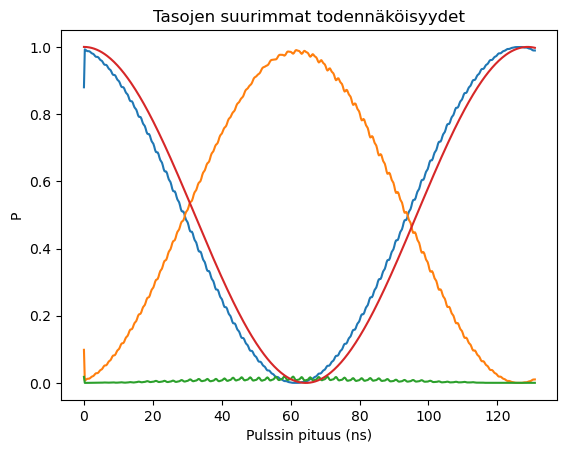

---------------------------------------------


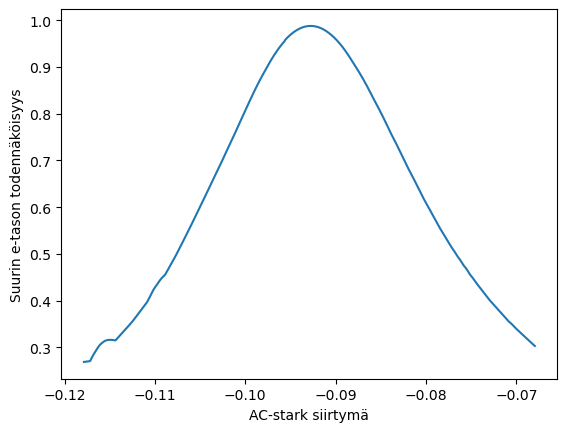

Amplitudi (GHz): 2.555681249291921
AC-stark siirtymä (GHz): -0.09275478963302844
E-tason suurin todennäköisyys: 0.990290109299172
Pulssin pituus (ns): 56.87235324994022
Rabi-taajuus (fourier):  0.008157431629179627


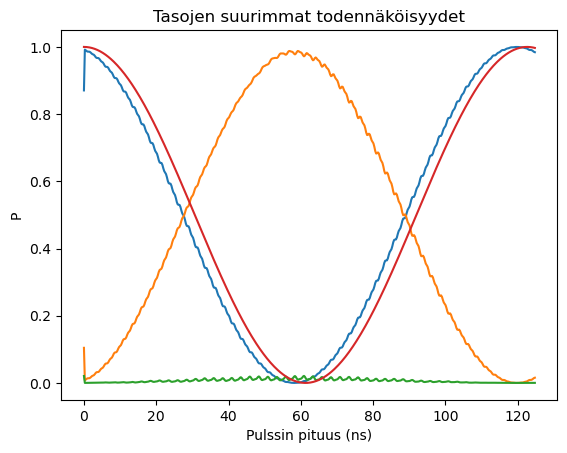

---------------------------------------------


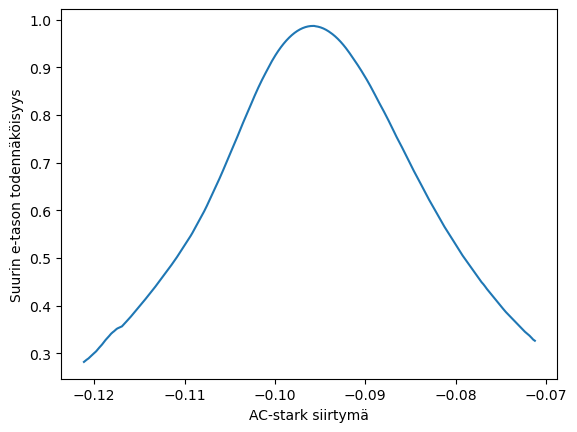

Amplitudi (GHz): 2.596247618328301
AC-stark siirtymä (GHz): -0.09573353601265902
E-tason suurin todennäköisyys: 0.9884639064984679
Pulssin pituus (ns): 54.756897624660795
Rabi-taajuus (fourier):  0.008559918691468889


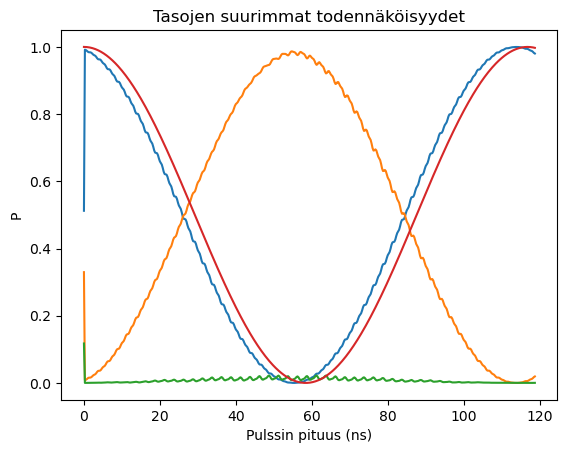

---------------------------------------------


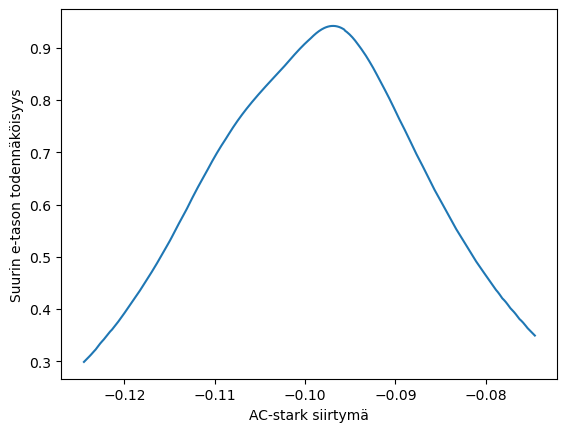

Amplitudi (GHz): 2.6368139873646808
AC-stark siirtymä (GHz): -0.09686731226941443
E-tason suurin todennäköisyys: 0.9679367032793771
Pulssin pituus (ns): 52.30377867306349
Rabi-taajuus (fourier):  0.008973590818206818


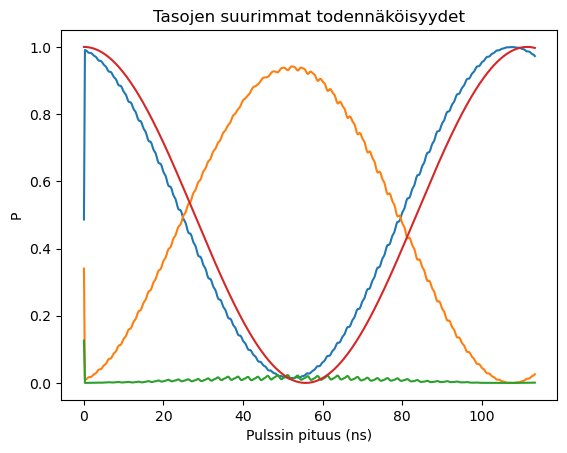

---------------------------------------------


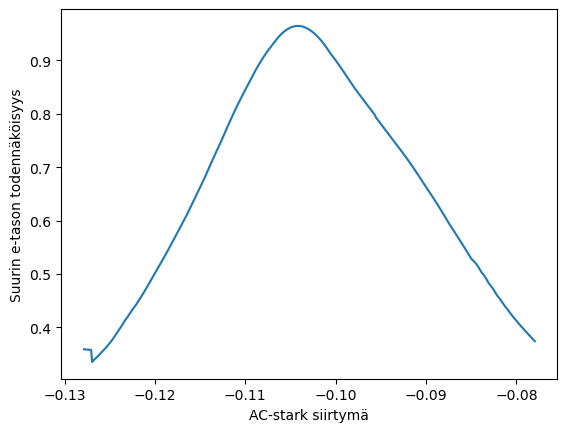

Amplitudi (GHz): 2.67738035640106
AC-stark siirtymä (GHz): -0.10415611840329465
E-tason suurin todennäköisyys: 0.9778086760280283
Pulssin pituus (ns): 50.092050876836474
Rabi-taajuus (fourier):  0.009397791964632977


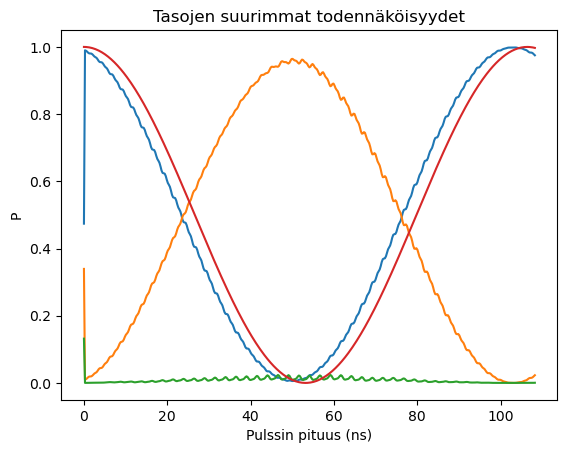

---------------------------------------------


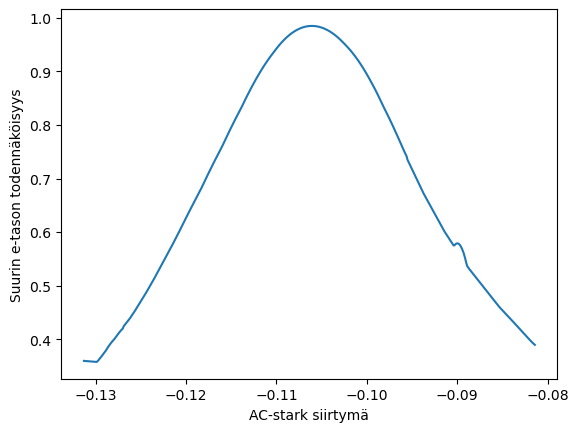

Amplitudi (GHz): 2.71794672543744
AC-stark siirtymä (GHz): -0.10609995441429979
E-tason suurin todennäköisyys: 0.9869134630836068
Pulssin pituus (ns): 47.39696387668117
Rabi-taajuus (fourier):  0.009832860469237186


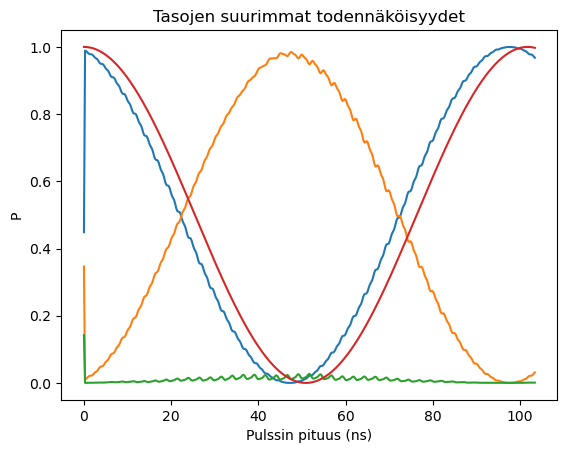

---------------------------------------------


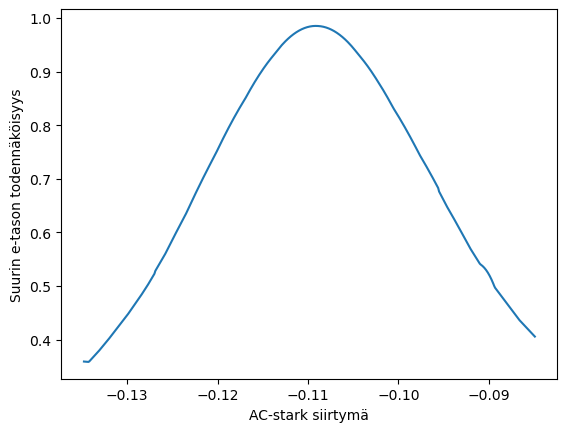

Amplitudi (GHz): 2.7585130944738196
AC-stark siirtymä (GHz): -0.10909882030242975
E-tason suurin todennäköisyys: 0.9861785409781625
Pulssin pituus (ns): 45.236826213228355
Rabi-taajuus (fourier):  0.010480927135466406


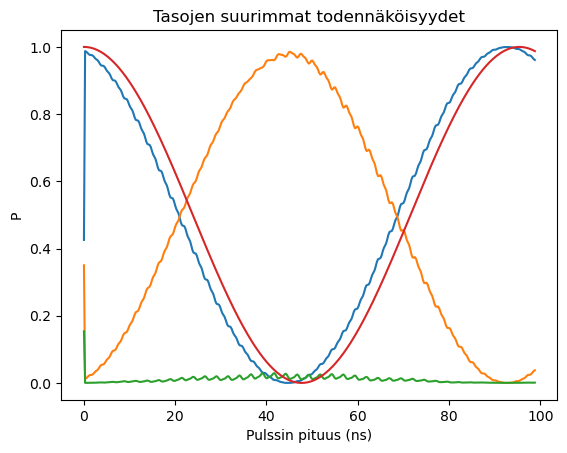

---------------------------------------------


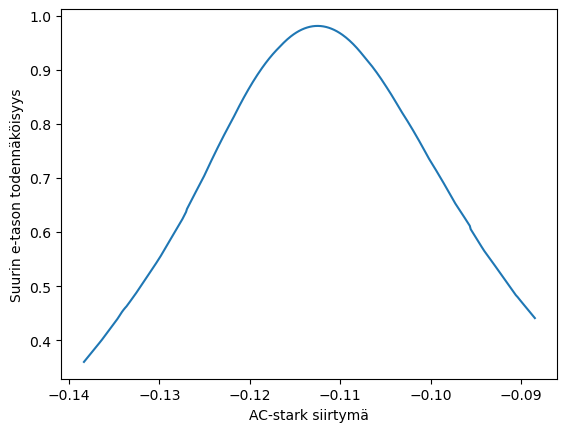

Amplitudi (GHz): 2.799079463510199
AC-stark siirtymä (GHz): -0.11245271606768455
E-tason suurin todennäköisyys: 0.9859198739223918
Pulssin pituus (ns): 42.57176731094747
Rabi-taajuus (fourier):  0.010946677737663234


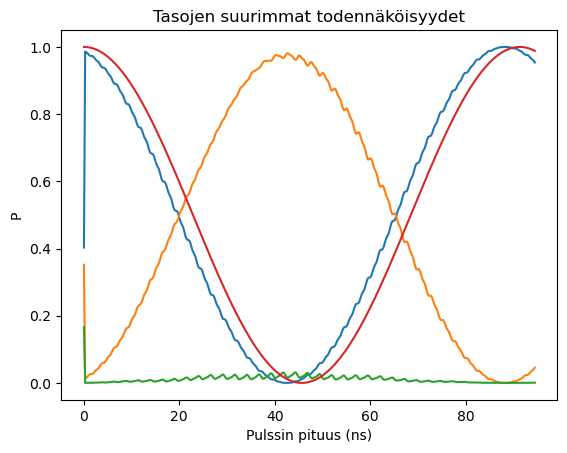

---------------------------------------------


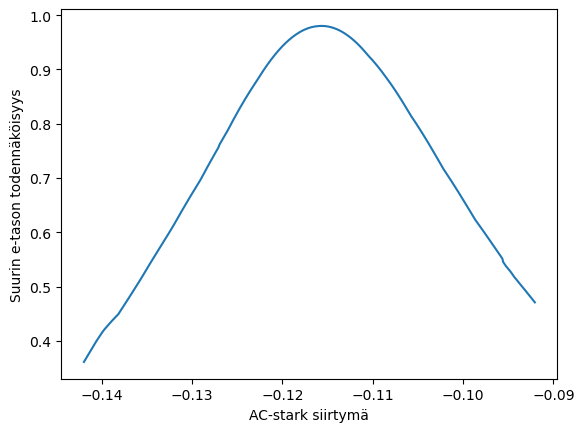

Amplitudi (GHz): 2.8396458325465788
AC-stark siirtymä (GHz): -0.11566164171006421
E-tason suurin todennäköisyys: 0.9810964783971705
Pulssin pituus (ns): 40.14163394380097
Rabi-taajuus (fourier):  0.011423523795117262


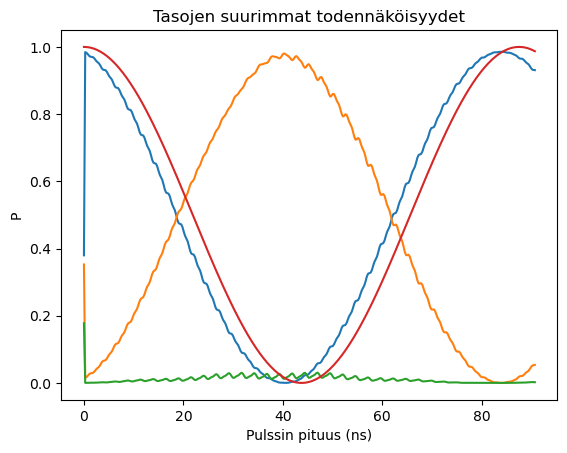

---------------------------------------------


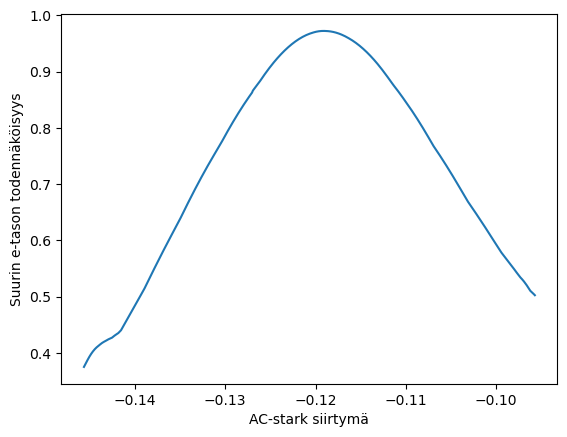

Amplitudi (GHz): 2.8802122015829585
AC-stark siirtymä (GHz): -0.1191255972295687
E-tason suurin todennäköisyys: 0.9812375998861859
Pulssin pituus (ns): 40.25439879157071
Rabi-taajuus (fourier):  0.011911404608566866


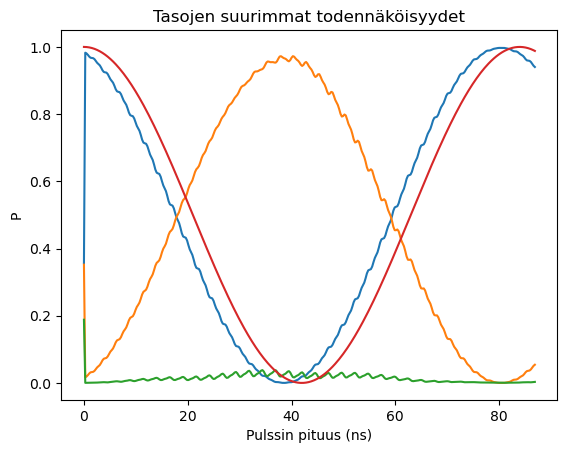

---------------------------------------------


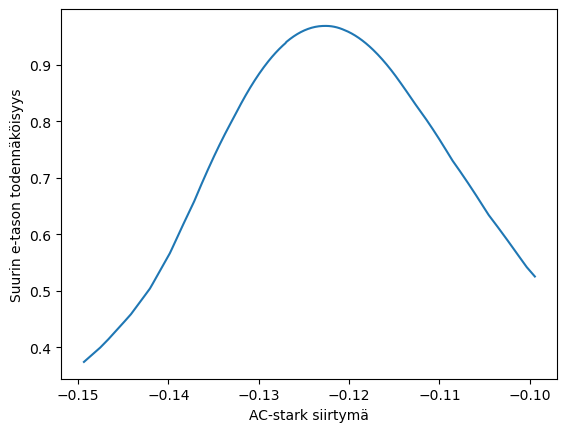

Amplitudi (GHz): 2.9207785706193383
AC-stark siirtymä (GHz): -0.12254458262619809
E-tason suurin todennäköisyys: 0.9798242381793051
Pulssin pituus (ns): 37.81149213754839
Rabi-taajuus (fourier):  0.012410731927104348


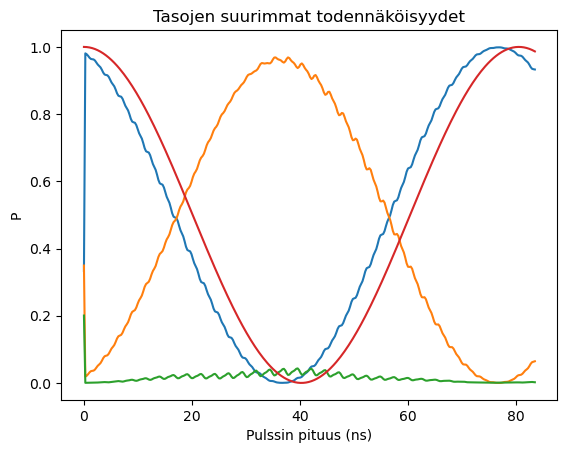

---------------------------------------------


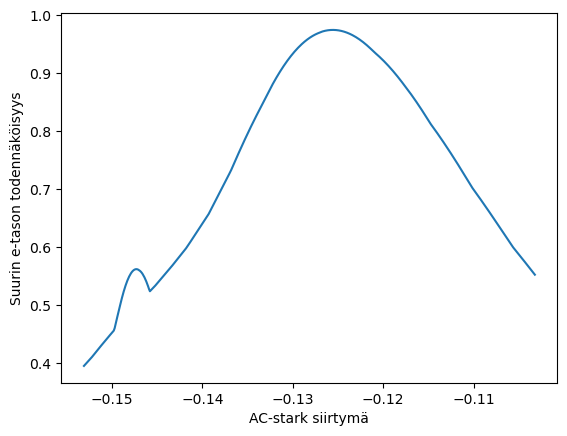

Amplitudi (GHz): 2.961344939655718
AC-stark siirtymä (GHz): -0.12561859789995233
E-tason suurin todennäköisyys: 0.975671932670454
Pulssin pituus (ns): 35.34501970982857
Rabi-taajuus (fourier):  0.012920969203176669


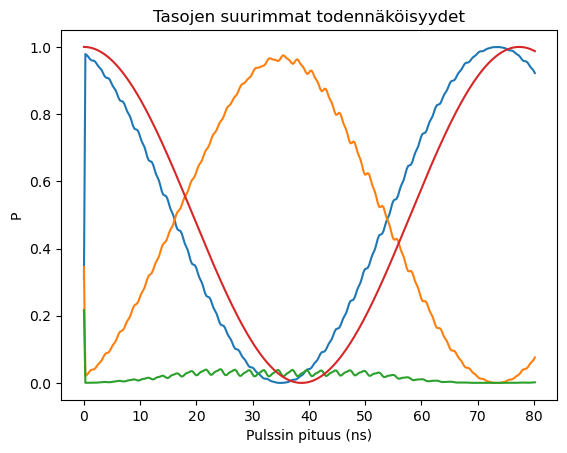

---------------------------------------------


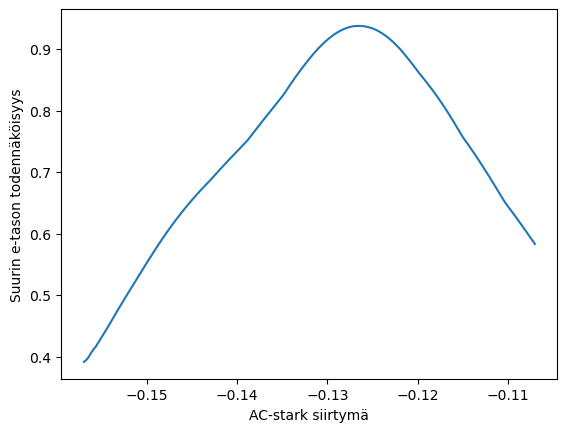

Amplitudi (GHz): 3.001911308692098
AC-stark siirtymä (GHz): -0.1265476430508314
E-tason suurin todennäköisyys: 0.9629339775932315
Pulssin pituus (ns): 33.06495374688171
Rabi-taajuus (fourier):  0.013700955755013396


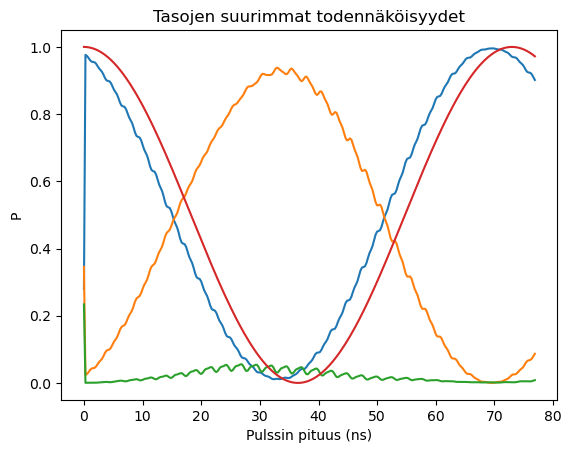

---------------------------------------------


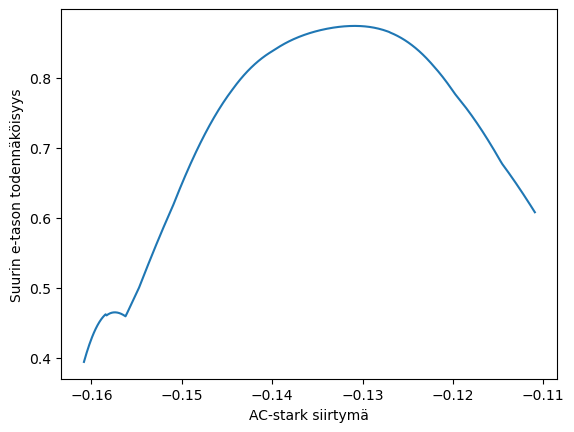

Amplitudi (GHz): 3.0424776777284777
AC-stark siirtymä (GHz): -0.13083171807883529
E-tason suurin todennäköisyys: 0.9566340520782484
Pulssin pituus (ns): 30.608766091398092
Rabi-taajuus (fourier):  0.013706382714382239


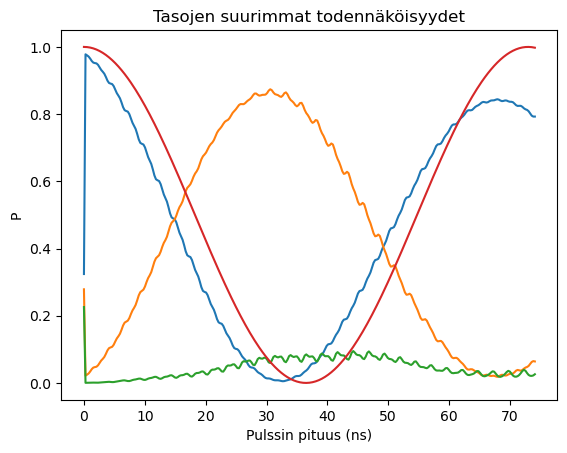

---------------------------------------------


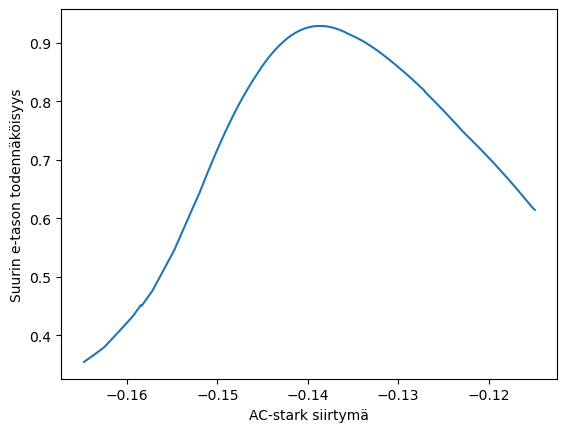

Amplitudi (GHz): 3.083044046764857
AC-stark siirtymä (GHz): -0.13867082298396405
E-tason suurin todennäköisyys: 0.9437331178621049
Pulssin pituus (ns): 30.806489311174023
Rabi-taajuus (fourier):  0.014517690799611722


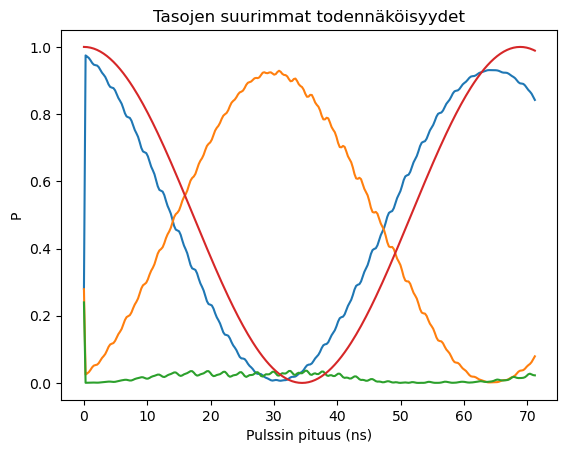

---------------------------------------------


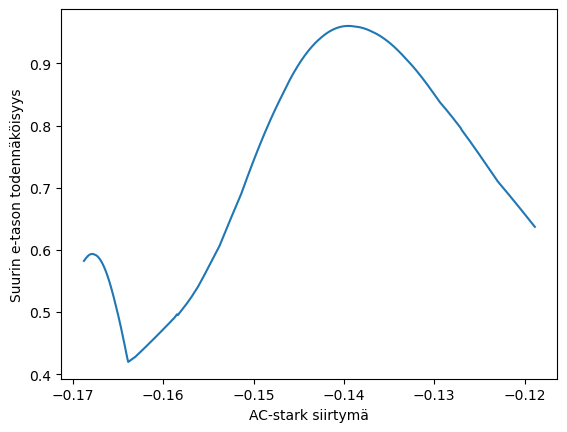

Amplitudi (GHz): 3.1236104158012368
AC-stark siirtymä (GHz): -0.13946495776621765
E-tason suurin todennäköisyys: 0.9682857098460915
Pulssin pituus (ns): 30.826662107109904
Rabi-taajuus (fourier):  0.015362338076057153


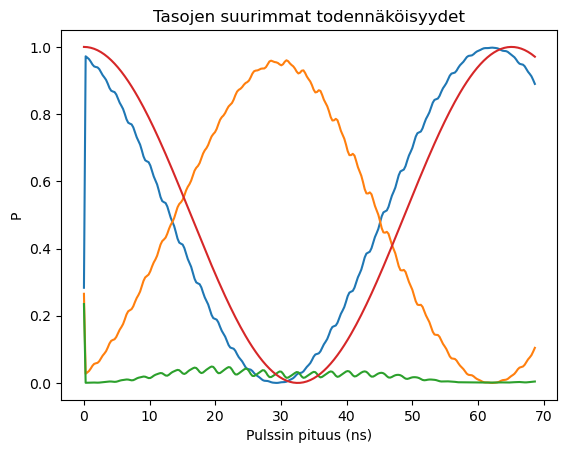

---------------------------------------------


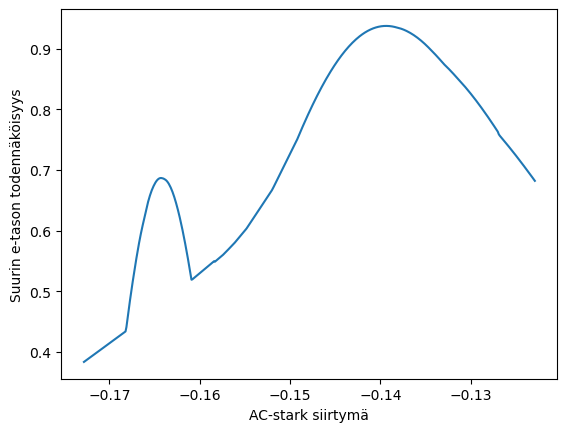

Amplitudi (GHz): 3.1641767848376166
AC-stark siirtymä (GHz): -0.13941412242559614
E-tason suurin todennäköisyys: 0.955580823290364
Pulssin pituus (ns): 28.494039481531267
Rabi-taajuus (fourier):  0.016239358973043055


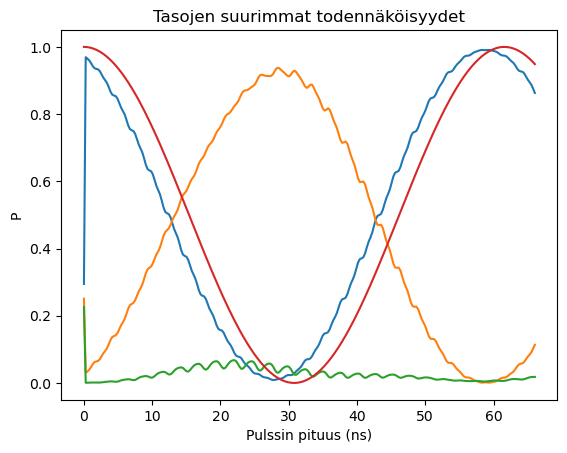

---------------------------------------------


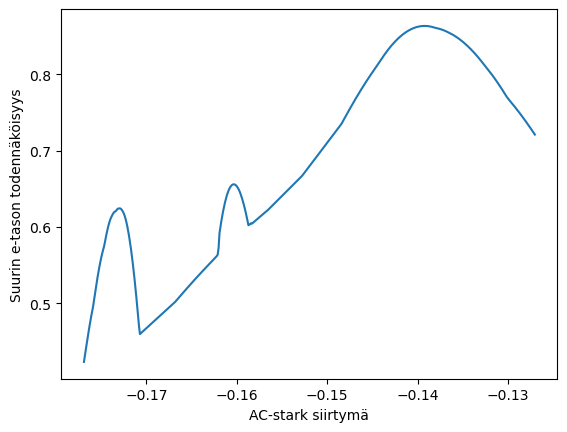

Amplitudi (GHz): 3.2047431538739963
AC-stark siirtymä (GHz): -0.13921831696209944
E-tason suurin todennäköisyys: 0.923597198492896
Pulssin pituus (ns): 28.23044497231027
Rabi-taajuus (fourier):  0.01683882309941411


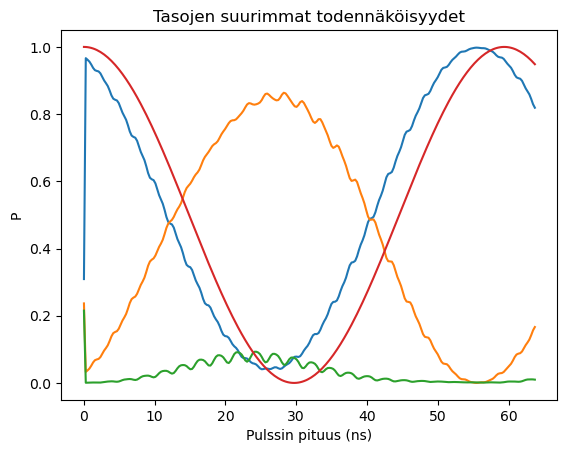

---------------------------------------------


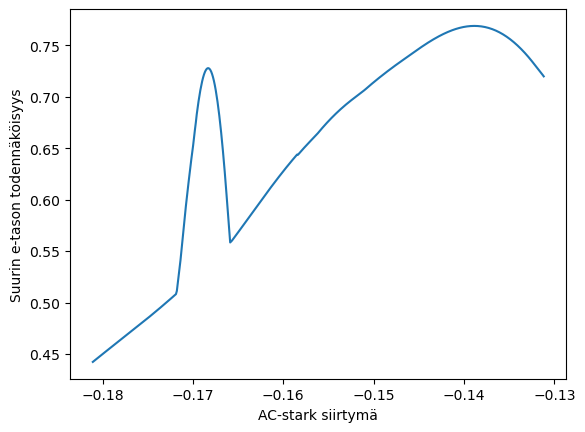

Amplitudi (GHz): 3.245309522910376
AC-stark siirtymä (GHz): -0.1388775413757276
E-tason suurin todennäköisyys: 0.8813729092277992
Pulssin pituus (ns): 23.04407286634315
Rabi-taajuus (fourier):  0.017772677971769697


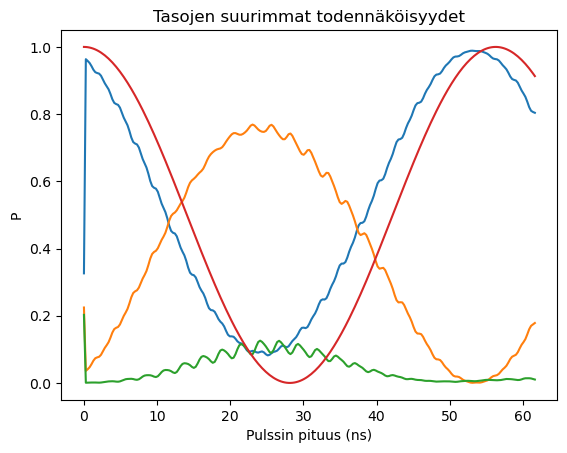

---------------------------------------------


In [9]:
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen

for i in range (60,81):
    A = qubit.frequency*(i/100)
    f_rabi=0.003235*A**2 - 0.006936*A + 0.004594 #Arvaus Rabi-taajuudelle
    AC_stark=-0.01672*A**2 + 0.005316*A + 0.002766 #Arvaus AC-stark siirtymälle
    params=find_params(qubit, A, evolution_eigenbasis,f_rabi,AC_stark)
    deltas.append(params[0])
    pulse_lengths.append(params[1])
    max_vals.append(params[2])
    data.append(params[3])
    
    f_d = qubit.frequency/3+deltas[-1] #Löydetty optimaalinen ajotaajuus

    vals=sim_pulse(f_d,A,evolution_eigenbasis,dim,f_rabi/50)

    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", deltas[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("Pulssin pituus (ns):", pulse_lengths[-1])

    g_vals=np.array([arr[0] for arr in vals[3]])
    e_vals=np.array([arr[1] for arr in vals[3]])
    f_vals=np.array([arr[2] for arr in vals[3]])

    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    #Taajuusavaruus
    T_floquet = 2*np.pi/(f_d)
    freqs = np.fft.rfftfreq(len(g_vals), d=(T_floquet/20)) 

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/50) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked])
    plt.plot(vals[4][:n_picked], e_vals[:n_picked])
    plt.plot(vals[4][:n_picked], f_vals[:n_picked])
    plt.plot(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

[2.43398214 2.47454851 2.51511488 2.55568125 2.59624762 2.63681399
 2.67738036 2.71794673 2.75851309 2.79907946 2.83964583 2.8802122
 2.92077857 2.96134494 3.00191131 3.04247768 3.08304405 3.12361042
 3.16417678 3.20474315 3.24530952]


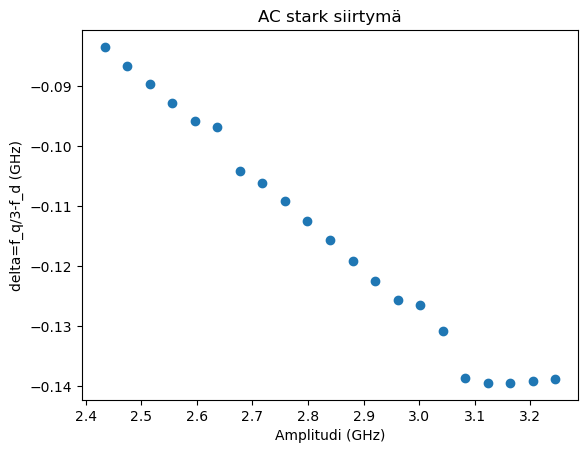

[np.float64(-0.08344872975688583), np.float64(-0.08656238650514185), np.float64(-0.08963107313052271), np.float64(-0.09275478963302844), np.float64(-0.09573353601265902), np.float64(-0.09686731226941443), np.float64(-0.10415611840329465), np.float64(-0.10609995441429979), np.float64(-0.10909882030242975), np.float64(-0.11245271606768455), np.float64(-0.11566164171006421), np.float64(-0.1191255972295687), np.float64(-0.12254458262619809), np.float64(-0.12561859789995233), np.float64(-0.1265476430508314), np.float64(-0.13083171807883529), np.float64(-0.13867082298396405), np.float64(-0.13946495776621765), np.float64(-0.13941412242559614), np.float64(-0.13921831696209944), np.float64(-0.1388775413757276)]


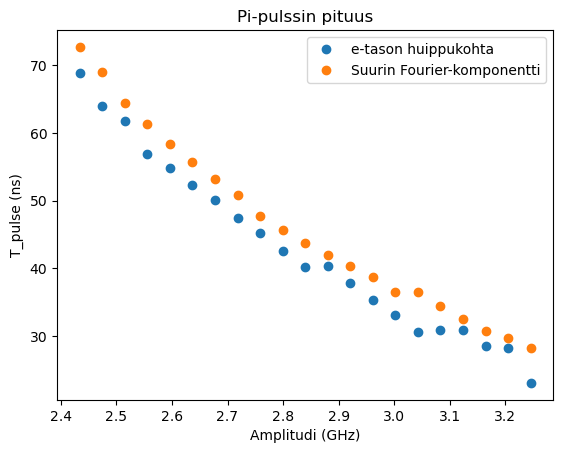

[np.float64(68.83573719695245), np.float64(64.04068733441792), np.float64(61.70810722995998), np.float64(56.87235324994022), np.float64(54.756897624660795), np.float64(52.30377867306349), np.float64(50.092050876836474), np.float64(47.39696387668117), np.float64(45.236826213228355), np.float64(42.57176731094747), np.float64(40.14163394380097), np.float64(40.25439879157071), np.float64(37.81149213754839), np.float64(35.34501970982857), np.float64(33.06495374688171), np.float64(30.608766091398092), np.float64(30.806489311174023), np.float64(30.826662107109904), np.float64(28.494039481531267), np.float64(28.23044497231027), np.float64(23.04407286634315)]


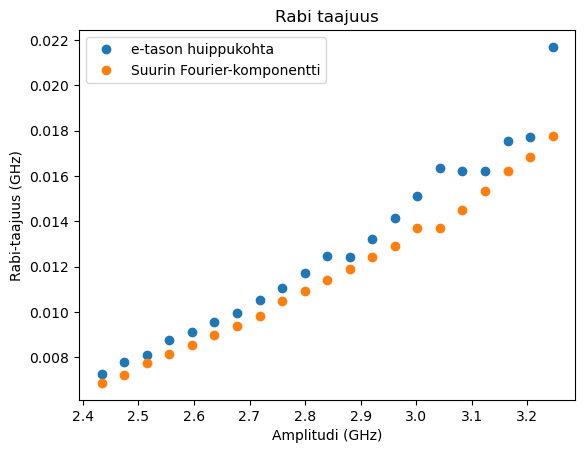

[np.float64(0.006877021898719922), np.float64(0.007239853364106555), np.float64(0.007765589314783416), np.float64(0.008157431629179627), np.float64(0.008559918691468889), np.float64(0.008973590818206818), np.float64(0.009397791964632977), np.float64(0.009832860469237186), np.float64(0.010480927135466406), np.float64(0.010946677737663234), np.float64(0.011423523795117262), np.float64(0.011911404608566866), np.float64(0.012410731927104348), np.float64(0.012920969203176669), np.float64(0.013700955755013396), np.float64(0.013706382714382239), np.float64(0.014517690799611722), np.float64(0.015362338076057153), np.float64(0.016239358973043055), np.float64(0.01683882309941411), np.float64(0.017772677971769697)]


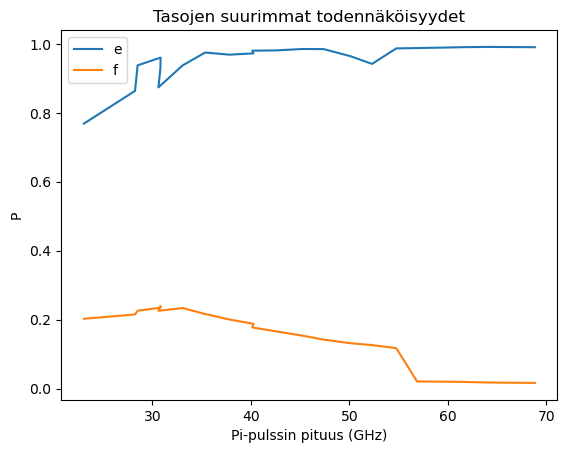

In [10]:
A_vals=(np.arange(21)*0.01+0.6)*qubit.frequency
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("delta=f_q/3-f_d (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.plot(A_vals, 1/(2*np.array(rabis)), 'o')
plt.legend(["e-tason huippukohta","Suurin Fourier-komponentti"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, 1/(2*np.array(pulse_lengths)), 'o')
plt.plot(A_vals, rabis, 'o')
plt.legend(["e-tason huippukohta","Suurin Fourier-komponentti"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.plot(pulse_lengths, e_vals)
plt.plot(pulse_lengths, f_vals)
plt.legend(["e","f"])
plt.xlabel("Pi-pulssin pituus (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()